In [1]:
import os
import numpy as np
import pickle
from statsmodels.stats.multitest import fdrcorrection
import scipy.stats as stats
import scipy.io as sio
import matplotlib.pyplot as plt
from nilearn.image import new_img_like
import pandas as pd
import nibabel as nib
import seaborn as sns
import csv
from nilearn import plotting
from rsatoolbox.inference import eval_fixed
from rsatoolbox.model import ModelFixed
from rsatoolbox.rdm import RDMs
from glob import glob
import nilearn.image as nlimg
from rsatoolbox.util.searchlight import get_volume_searchlight, get_searchlight_RDMs, evaluate_models_searchlight

In [2]:
def upper_tri(RDM):
    """upper_tri returns the upper triangular index of an RDM

    Args:
        RDM 2Darray: squareform RDM

    Returns:
        1D array: upper triangular vector of the RDM
    """
    # returns the upper triangle
    m = RDM.shape[0]
    r, c = np.triu_indices(m, 1)
    return RDM[r, c]

In [3]:
import matplotlib.colors
def RDMcolormapObject(direction=1):
    """
    Returns a matplotlib color map object for RSA and brain plotting
    """
    if direction == 0:
        cs = ['yellow', 'red', 'gray', 'turquoise', 'blue']
    elif direction == 1:
        cs = ['blue', 'turquoise', 'gray', 'red', 'yellow']
    else:
        raise ValueError('Direction needs to be 0 or 1')
    cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", cs)
    return cmap

In [3]:
tmp_image_path = '../IAPS_fMRI_RSA/fMRI/nifti/Nt1.img'
# load one image to get the dimensions and make the mask

tmp_img = nib.load(tmp_image_path)

# Create mask

### Using subject fMRI data to create mask

    Avoid using subject data that included eyeball voxels. Subjects 4, 5, 10, 11, 15, 16, and 17 fMRI data do not contain eyeball voxels. 

c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\plotting\html_stat_map.py:219: FutureWarning: Default resolution of the MNI template will change from 2mm to 1mm in version 0.10.0
  bg_img = load_mni152_template()
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\numpy\core\fromnumeric.py:758: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\image\resampling.py:545: UserWarning: Casting data from int32 to float32
  warnings.warn("Casting data from %s to %s" % (data.dtype.name, aux))
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\image\resampling.py:274: UserWarning: Resampling binary images with continuous or linear interpolation. This might lead to unexpected results. You might consider using nearest interpolation instead.
  warnings.warn("Resampling binary images with continuous or "



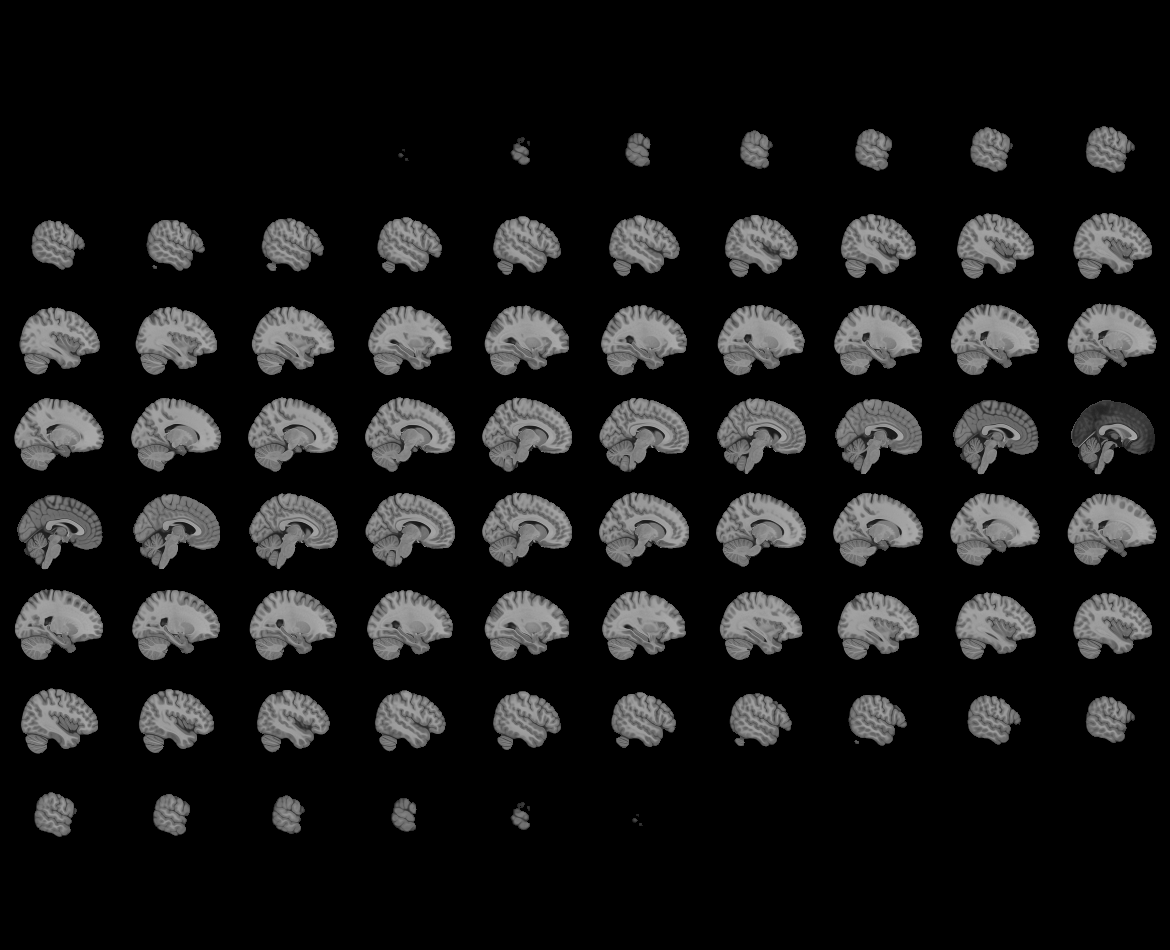
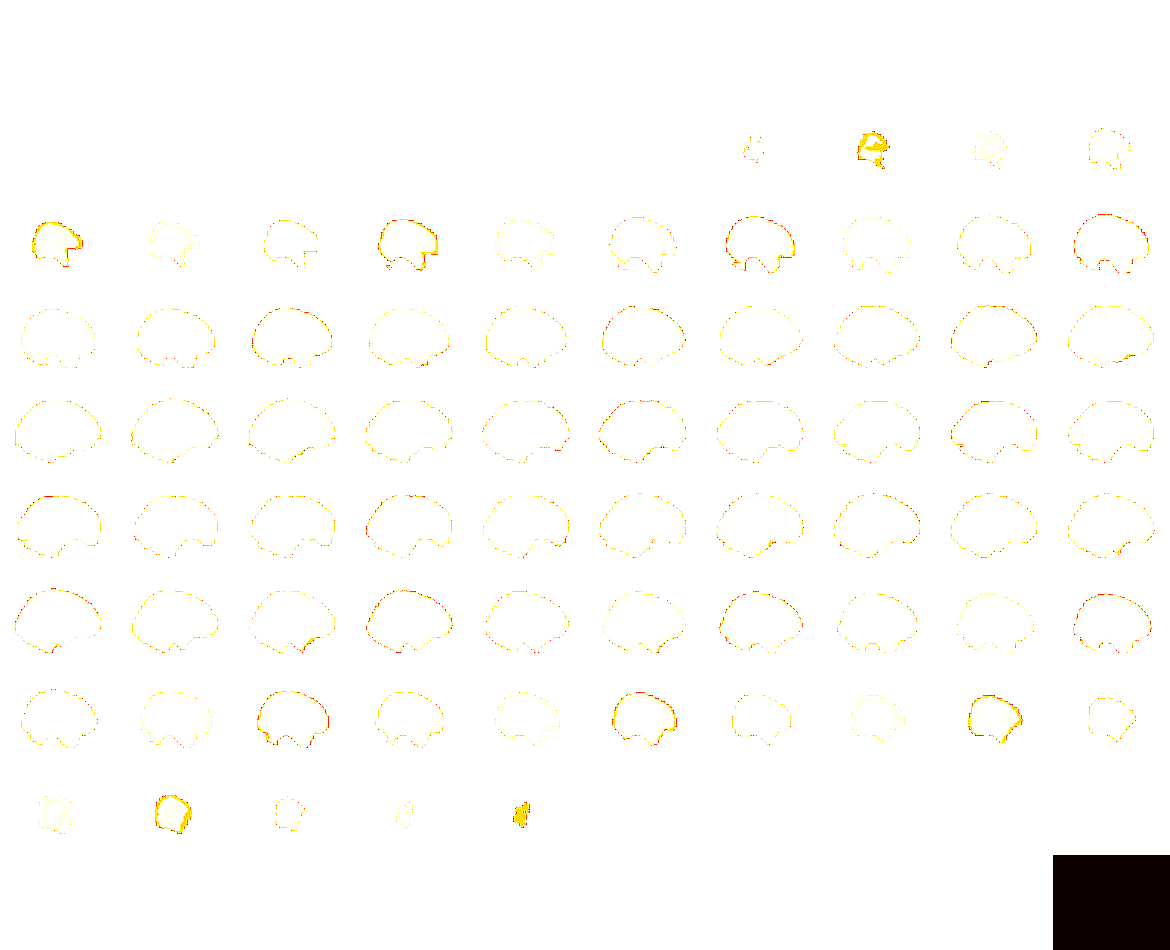

In [18]:
stimuli = ['Pl','Nt','Up']
no_eyeballvoxel_subjects = [4,5,10,11,15,16,17]

sub_mask_list = []
for s, sub in enumerate(no_eyeballvoxel_subjects):

    mask_list = []
    for i, stim in enumerate(stimuli):
        image_path = '../IAPS_fMRI_RSA/fMRI/{}{}.mat'.format(stim,sub-1)
        # load one image to get the dimensions and make the mask
        image_file = sio.loadmat(image_path)
        mask_file = image_file['{}'.format(stim)] #(153594, 100)
        mask_list.append(mask_file)

    allmask = np.hstack(mask_list)
    mask_sum = np.sum(allmask, axis = 1)
    sub_mask_list.append(mask_sum)

allsub_mask = np.vstack(sub_mask_list)
allsub_mask_sum = np.sum(allsub_mask, axis = 0)
mask_flat = (~np.isnan(allsub_mask_sum)).astype(int)
x, y, z = 53,63,46
mask_reshape = mask_flat.reshape(z, y, x)
mask = np.moveaxis(mask_reshape, [0,1,2], [2,1,0])

tmp_image_path = '../IAPS_fMRI_RSA/fMRI/nifti/Nt1.img'
# load one image to get the dimensions and make the mask

tmp_img = nib.load(tmp_image_path)
mask_3d = new_img_like(tmp_img, mask)
view = plotting.view_img(mask_3d)
view

### Export mask 

In [19]:
# Export mask
np.save("./mask.npy", mask)

### Import mask

In [4]:
mask = np.load("./mask.npy")

c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\numpy\core\fromnumeric.py:758: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\image\resampling.py:545: UserWarning: Casting data from int32 to float32
  warnings.warn("Casting data from %s to %s" % (data.dtype.name, aux))
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\image\resampling.py:274: UserWarning: Resampling binary images with continuous or linear interpolation. This might lead to unexpected results. You might consider using nearest interpolation instead.
  warnings.warn("Resampling binary images with continuous or "



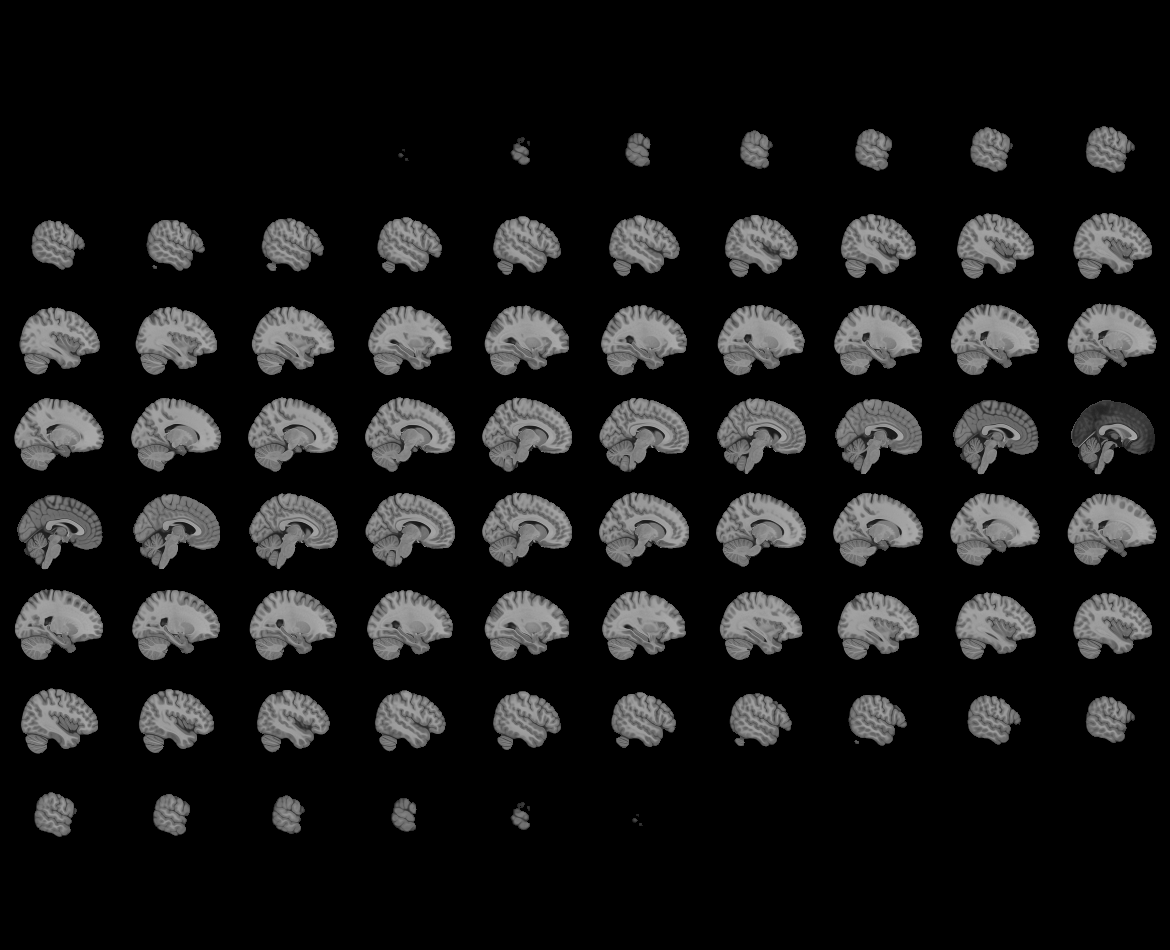
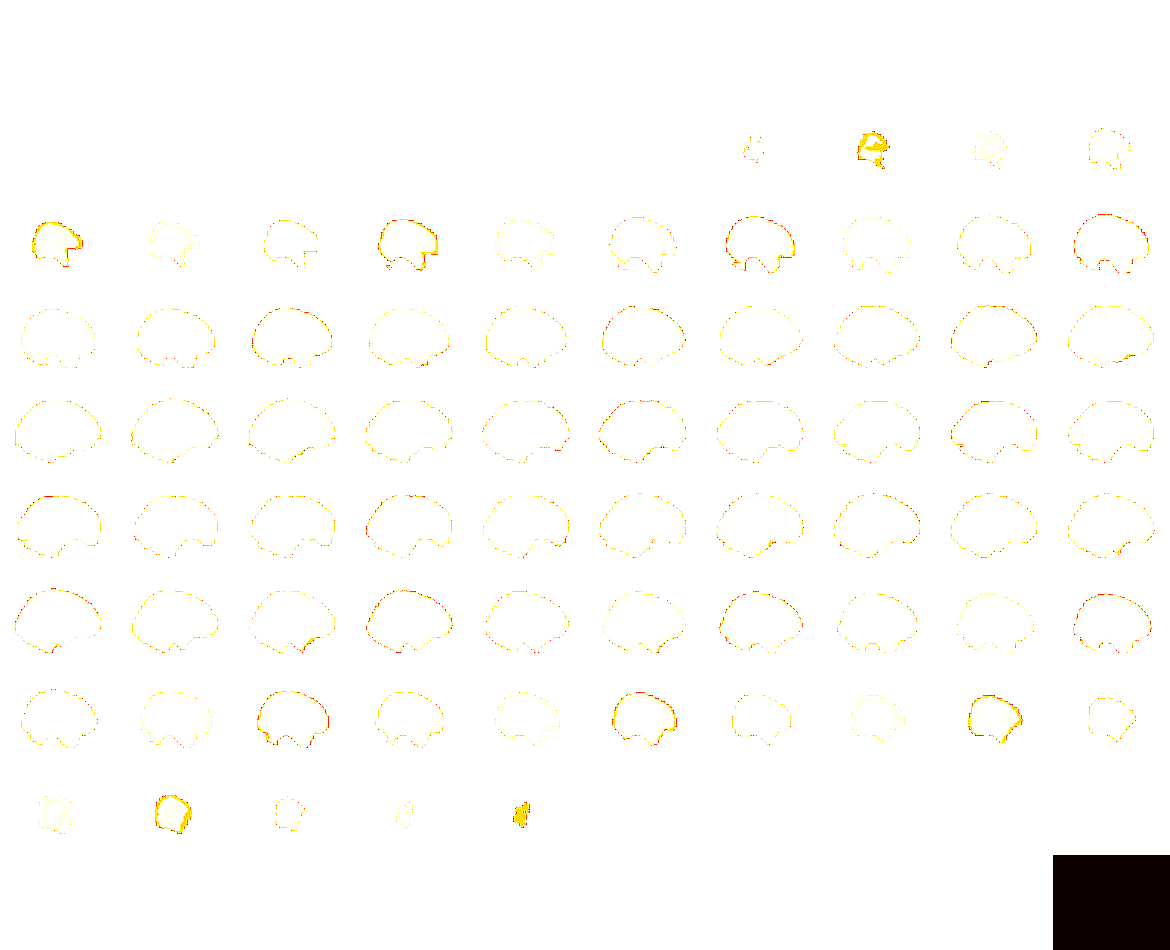

In [21]:
tmp_image_path = '../IAPS_fMRI_RSA/fMRI/nifti/Nt1.img'
# load one image to get the dimensions and make the mask

tmp_img = nib.load(tmp_image_path)
mask_3d = new_img_like(tmp_img, mask)
view = plotting.view_img(mask_3d)
view

# Create searchlight centers and neighbours

In [5]:
centers, neighbors = get_volume_searchlight(mask, radius=5, threshold=0.5)

Finding searchlights...: 100%|██████████| 59159/59159 [00:26<00:00, 2230.30it/s]


Found 56949 searchlights


# Load fMRI RDMs

### Stimuli

In [6]:
stim_file = pd.read_csv('../IAPS_fMRI_RSA/fmri_conditions_trial_ordered.csv')
# stim_Nt = stim_file[0:100]
# stim_Pl = stim_file[100:200].reset_index()
stim_Up = stim_file[200:300].reset_index()

In [7]:
# stim_Nt_id = pd.DataFrame(stim_Nt[['stim_order']]).T
# stim_Nt_id.shape
# stim_Pl_id = pd.DataFrame(stim_Pl[['stim_order']]).T
# stim_Pl_id.shape
stim_Up_id = pd.DataFrame(stim_Up[['stim_order']]).T
stim_Up_id.shape
# print("Netrual    Type: {} Shape/Length: {}".format(type(stim_Nt_id), stim_Nt_id.shape))
# print("Pleasant   Type: {} Shape/Length: {}".format(type(stim_Pl_id), stim_Pl_id.shape))
print("Unpleasant Type: {} Shape/Length: {}".format(type(stim_Up_id), stim_Up_id.shape))

Unpleasant Type: <class 'pandas.core.frame.DataFrame'> Shape/Length: (1, 100)


In [8]:
allsub_avg = []

subjects = 20
for i in range(subjects):
    sub_avg = []
    #Pleasant
    # mat_name_Pl = '../IAPS_fMRI_RSA/fMRI/Pl{}.mat'.format(i+1)
    # mat_file_Pl = sio.loadmat(mat_name_Pl)
    # data_Pl = mat_file_Pl['Pl'] #(153594, 100)
    # data_Pl_reshape = data_Pl.reshape(46, 63, 53, 100)
    # data_Pl_reorder = np.moveaxis(data_Pl_reshape, [0,1,2,3], [2,1,0,3])
    # data_Pl_reorder_flat = np.reshape(data_Pl_reorder, (153594,100))
    # data_Pl_df = pd.DataFrame(data_Pl_reorder_flat) #(153594, 100)
    # Pl_df = pd.concat([stim_Pl_id, data_Pl_df]) #(153595,100)
    # Pl_df = Pl_df.T
    # Pl_df_gr = Pl_df.groupby('stim_order').mean() #(20, 153594)
    # Pl_df_gr = Pl_df_gr.reset_index(drop=True) #(20, 153594) 

    # #Neutral
    # mat_name_Nt = '../IAPS_fMRI_RSA/fMRI/Nt{}.mat'.format(i+1)
    # mat_file_Nt = sio.loadmat(mat_name_Nt)
    # data_Nt = mat_file_Nt['Nt'] #(153594, 100)
    # data_Nt_reshape = data_Nt.reshape(46, 63, 53, 100)
    # data_Nt_reorder = np.moveaxis(data_Nt_reshape, [0,1,2,3], [2,1,0,3])
    # data_Nt_reorder_flat = np.reshape(data_Nt_reorder, (153594,100))
    # data_Nt_df = pd.DataFrame(data_Nt_reorder_flat) #(153594, 100)
    # Nt_df = pd.concat([stim_Nt_id,data_Nt_df]) #(153595,100)
    # Nt_df = Nt_df.T
    # Nt_df_gr = Nt_df.groupby('stim_order').mean() #(20, 153594)
    # Nt_df_gr = Nt_df_gr.reset_index(drop=True) #(20, 153594) 


    # #Unpleasant
    mat_name_Up = '../IAPS_fMRI_RSA/fMRI/Up{}.mat'.format(i+1)
    mat_file_Up = sio.loadmat(mat_name_Up)
    data_Up = mat_file_Up['Up'] #(153594, 100)
    data_Up_reshape = data_Up.reshape(46, 63, 53, 100)
    data_Up_reorder = np.moveaxis(data_Up_reshape, [0,1,2,3], [2,1,0,3])
    data_Up_reorder_flat = np.reshape(data_Up_reorder, (153594,100))
    data_Up_df = pd.DataFrame(data_Up_reorder_flat) #(153594, 100)
    Up_df = pd.concat([stim_Up_id, data_Up_df]) #(153595,100)
    Up_df = Up_df.T
    Up_df_gr = Up_df.groupby('stim_order').mean() #(20, 153594)
    Up_df_gr = Up_df_gr.reset_index(drop=True) #(20, 153594) 

    sub_df = pd.concat([Up_df_gr])
    allsub_avg.append(sub_df)

In [11]:
allsub_avg[1].shape

(20, 153594)

In [12]:
len(allsub_avg)

20

### Export neural RDM

In [28]:
# dbfile= open('./outputs/20sub_fmri_rdm', 'ab')
# pickle.dump(allsub_avg, dbfile)                     
# dbfile.close()

### Import neural RDM

In [6]:
# dbfile = open('./outputs/20sub_fmri_rdm', 'rb')     
# allsub_avg = pickle.load(dbfile)

### Plot one stimulus image out of the 60 images 

c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\_utils\niimg.py:63: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  warn(
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\numpy\core\fromnumeric.py:758: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



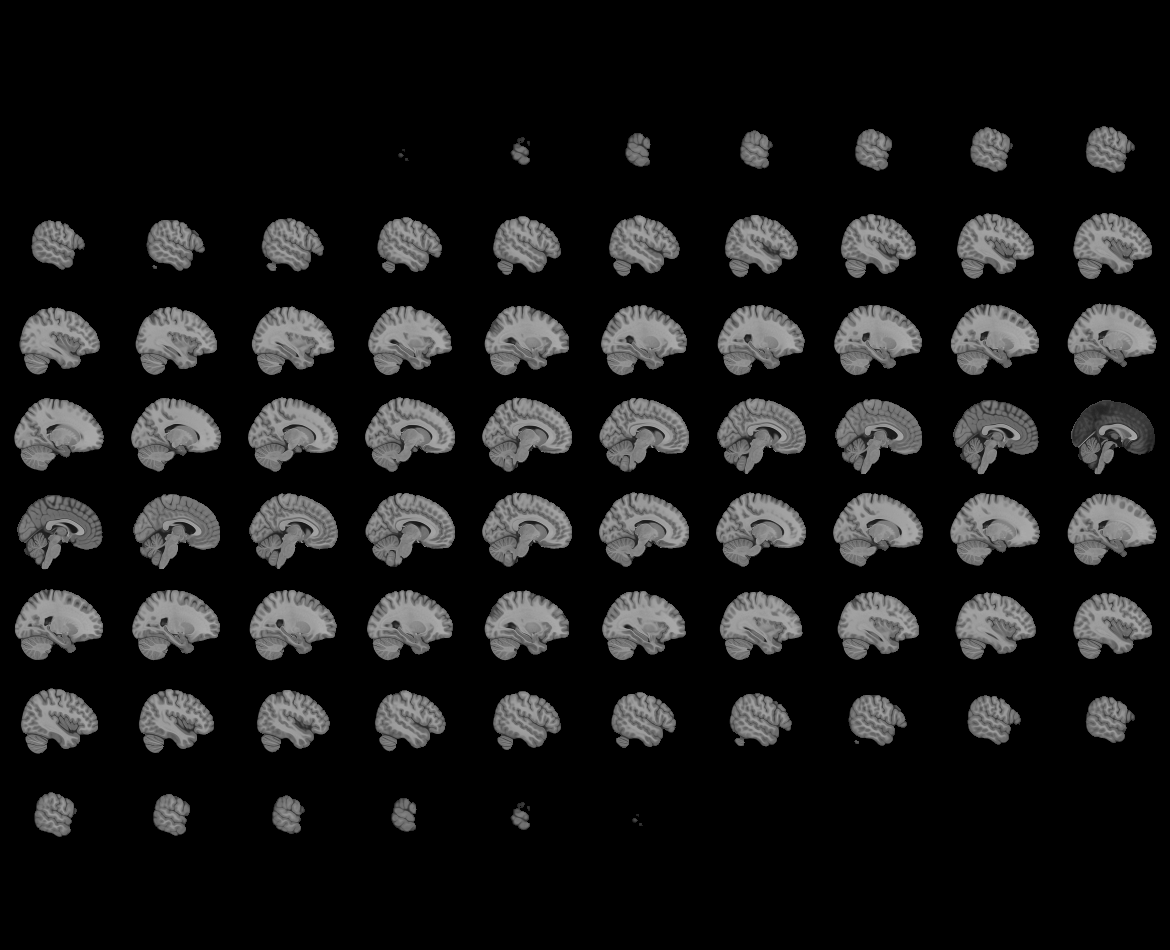
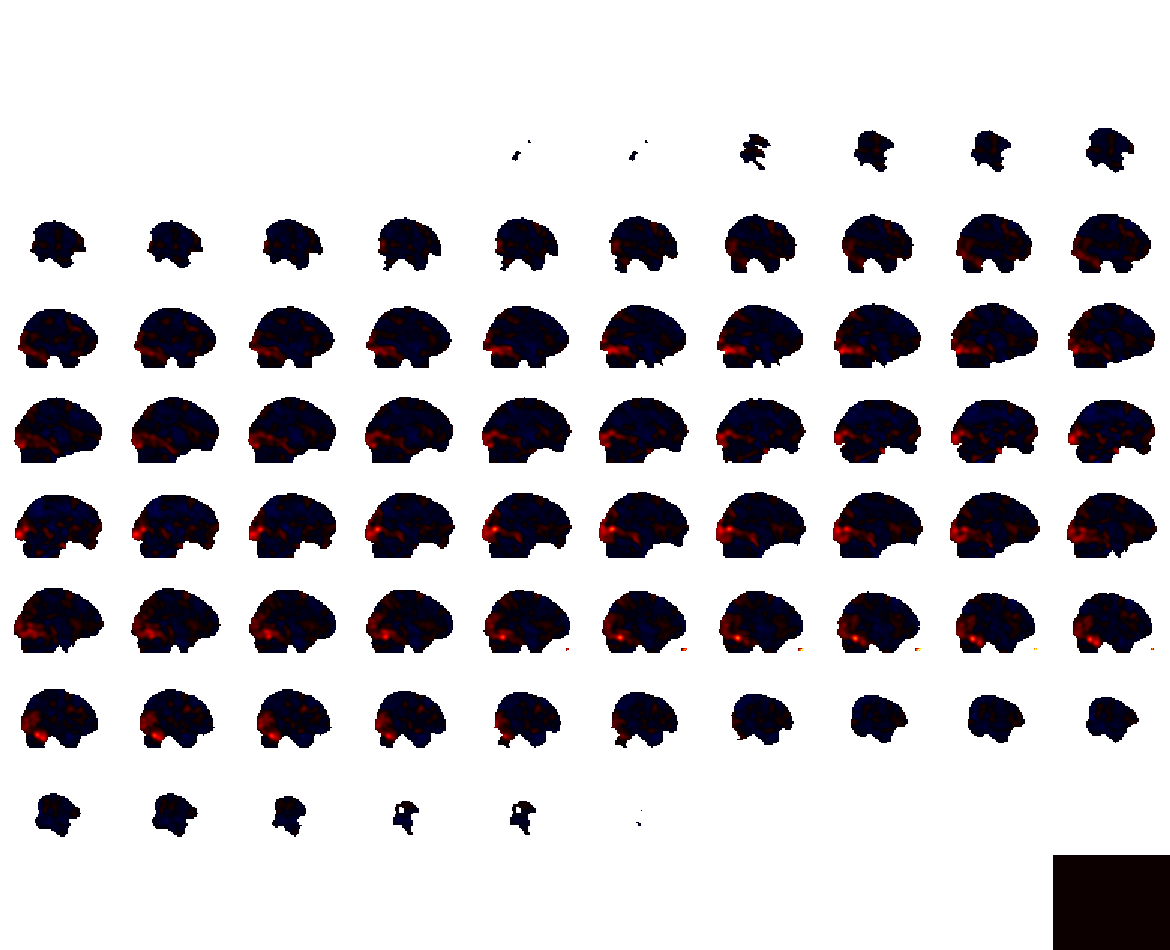

In [30]:
plot_slice = np.array(allsub_avg[10])[1,:]
plot_slice_3d = plot_slice.reshape(53, 63, 46)
plot_neural_rdm_cont1 = new_img_like(tmp_img, plot_slice_3d)
view = plotting.view_img(plot_neural_rdm_cont1)
view

# Load valence RDMs

In [9]:
rdm_valence = pd.read_csv("../IAPS_behavioral_RDM/rdm_valence.csv", index_col=0)
rdm_valence_arr = np.array(rdm_valence)
rdm_unpleasure_arr = rdm_valence_arr[-20:, -20:]

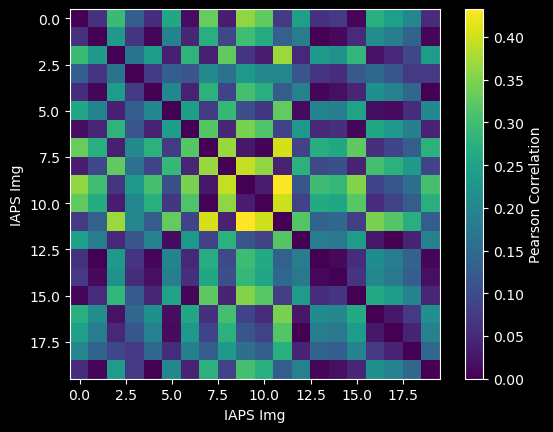

In [10]:
plt.style.use('dark_background')
# make plot
fig, ax = plt.subplots()
  
# show image
shw = ax.imshow(rdm_unpleasure_arr)
  
# make bar
bar = plt.colorbar(shw)
  
# show plot with labels
plt.xlabel('IAPS Img')
plt.ylabel('IAPS Img')
bar.set_label('Pearson Correlation')
plt.show()

In [11]:
normalized_rdm_unpleasure_arr = (rdm_unpleasure_arr - np.min(rdm_unpleasure_arr)) / (np.max(rdm_unpleasure_arr) - np.min(rdm_unpleasure_arr))


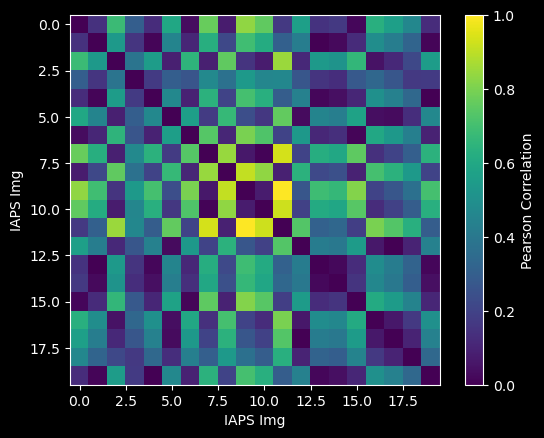

In [12]:
plt.style.use('dark_background')
# make plot
fig, ax = plt.subplots()
  
# show image
shw = ax.imshow(normalized_rdm_unpleasure_arr)
  
# make bar
bar = plt.colorbar(shw)
  
# show plot with labels
plt.xlabel('IAPS Img')
plt.ylabel('IAPS Img')
bar.set_label('Pearson Correlation')
plt.show()

In [13]:
unpleasure_model = ModelFixed('Valence RDM', upper_tri(normalized_rdm_unpleasure_arr))

## Searchlight analysis

In [14]:
eval_score_list = []
RDM_brain_list = []

for i in range(20):
    subj_data = allsub_avg[i]
    subj_data_2d = np.nan_to_num(subj_data)

    image_value = np.arange(20)
    SL_RDM = get_searchlight_RDMs(subj_data_2d, centers, neighbors, image_value, method='correlation')

    eval_results = evaluate_models_searchlight(SL_RDM, unpleasure_model, eval_fixed, method='spearman', n_jobs=3)
    # get the evaulation score for each voxel
    # We only have one model, but evaluations returns a list. By using float we just grab the value within that list
    eval_score = [np.float(e.evaluations) for e in eval_results]
    # Create an 3D array, with the size of mask, and
    x, y, z = mask.shape
    RDM_brain = np.zeros([x*y*z])
    RDM_brain[list(SL_RDM.rdm_descriptors['voxel_index'])] = eval_score
    RDM_brain = RDM_brain.reshape([x, y, z])

    eval_score_list.append(eval_score)
    RDM_brain_list.append(RDM_brain)

Evaluating models for each searchlight: 100%|██████████| 56949/56949 [00:48<00:00, 1167.77it/s]
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_6444\1041430818.py:14: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  eval_score = [np.float(e.evaluations) for e in eval_results]
Evaluating models for each searchlight: 100%|██████████| 56949/56949 [00:40<00:00, 1411.76it/s]


In [15]:
SL_RDM.dissimilarities.shape

(56949, 190)

### Export/Load searchlight results

In [16]:
# Export
# Save the evaluation scores and RDMs.
pd.DataFrame(eval_score_list).to_csv("./outputs/searchlight_results/20sub_SL_unpleasure_eval_score.csv")

dbfile= open('./outputs/searchlight_results/20sub_SL_unpleasure_SL_RDM', 'ab')
pickle.dump(SL_RDM, dbfile)                     
dbfile.close()

dbfile= open('./outputs/searchlight_results/20sub_SL_unpleasure', 'ab')
pickle.dump(RDM_brain_list, dbfile)                     
dbfile.close()


In [17]:
# Import
eval_score_list = pd.read_csv("./outputs/searchlight_results/20sub_SL_valence_eval_score.csv",header=0, index_col=0)
dbfile = open('./outputs/searchlight_results/20sub_SL_valence', 'rb')     
RDM_brain_list = pickle.load(dbfile)

### Plot results

In [13]:
eval_score_list2 = eval_score_list.values.tolist()

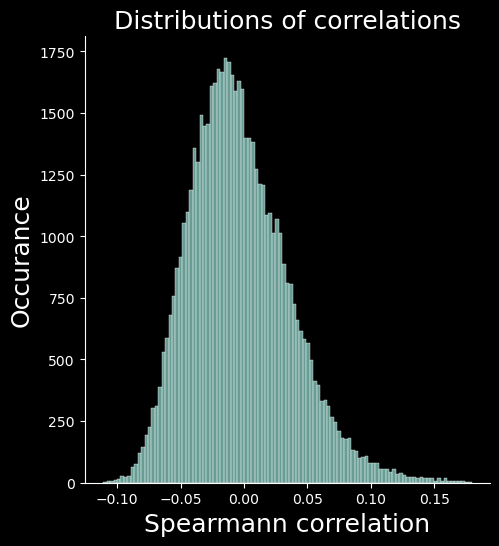

In [14]:
sns.displot(eval_score_list2[0])
plt.title('Distributions of correlations', size=18)
plt.ylabel('Occurance', size=18)
plt.xlabel('Spearmann correlation', size=18)
sns.despine()
plt.show()

# Group analysis
When these results are used for group analysis across multiple subjects, it may be good to Fisher-transform the correlation values, so that they are more normally distributed.

### Fisher z transformation

In [17]:
eval_score_array = np.array(eval_score_list)
seed_to_voxel_correlations_fisher_z = np.arctanh(eval_score_array)

In [18]:
seed_to_voxel_correlations_fisher_z.shape

(20, 56949)

### t-test

In [19]:
t_stat_list = []
p_value_list = []

for i in range(seed_to_voxel_correlations_fisher_z.shape[-1]):
    t_statistic, p_value = stats.ttest_1samp(a=seed_to_voxel_correlations_fisher_z[:,i], popmean=0) 
    t_stat_list.append(t_statistic)
    p_value_list.append(p_value)

t_stat_array = np.array(t_stat_list)
p_value_array = np.array(p_value_list)

In [20]:
x, y, z = mask.shape
p_value_brain = np.empty([x*y*z])
p_value_brain[list(SL_RDM.rdm_descriptors['voxel_index'])] = p_value_array
# neg_log_p = np.log10(p_value_brain) * (-1)
# neg_log_p_brain = neg_log_p.reshape([x, y, z])

### Corrected p-values

In [21]:
reject_decision, corrected_pvalue = fdrcorrection(p_value_array, alpha=0.05, method='indep', is_sorted=False)

In [22]:
x, y, z = mask.shape
corrected_p_value_array = np.empty([x*y*z])
corrected_p_value_array[list(SL_RDM.rdm_descriptors['voxel_index'])] = corrected_pvalue
neg_log_corrected_p = np.log10(corrected_p_value_array) * (-1)
neg_log_corrected_p_brain = neg_log_corrected_p.reshape([x, y, z])

C:\Users\yujunchen\AppData\Local\Temp\ipykernel_6444\2821812379.py:4: RuntimeWarning: divide by zero encountered in log10
  neg_log_corrected_p = np.log10(corrected_p_value_array) * (-1)


c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\_utils\niimg.py:63: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  warn(
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\plotting\html_stat_map.py:219: FutureWarning: Default resolution of the MNI template will change from 2mm to 1mm in version 0.10.0
  bg_img = load_mni152_template()
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\numpy\core\fromnumeric.py:758: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



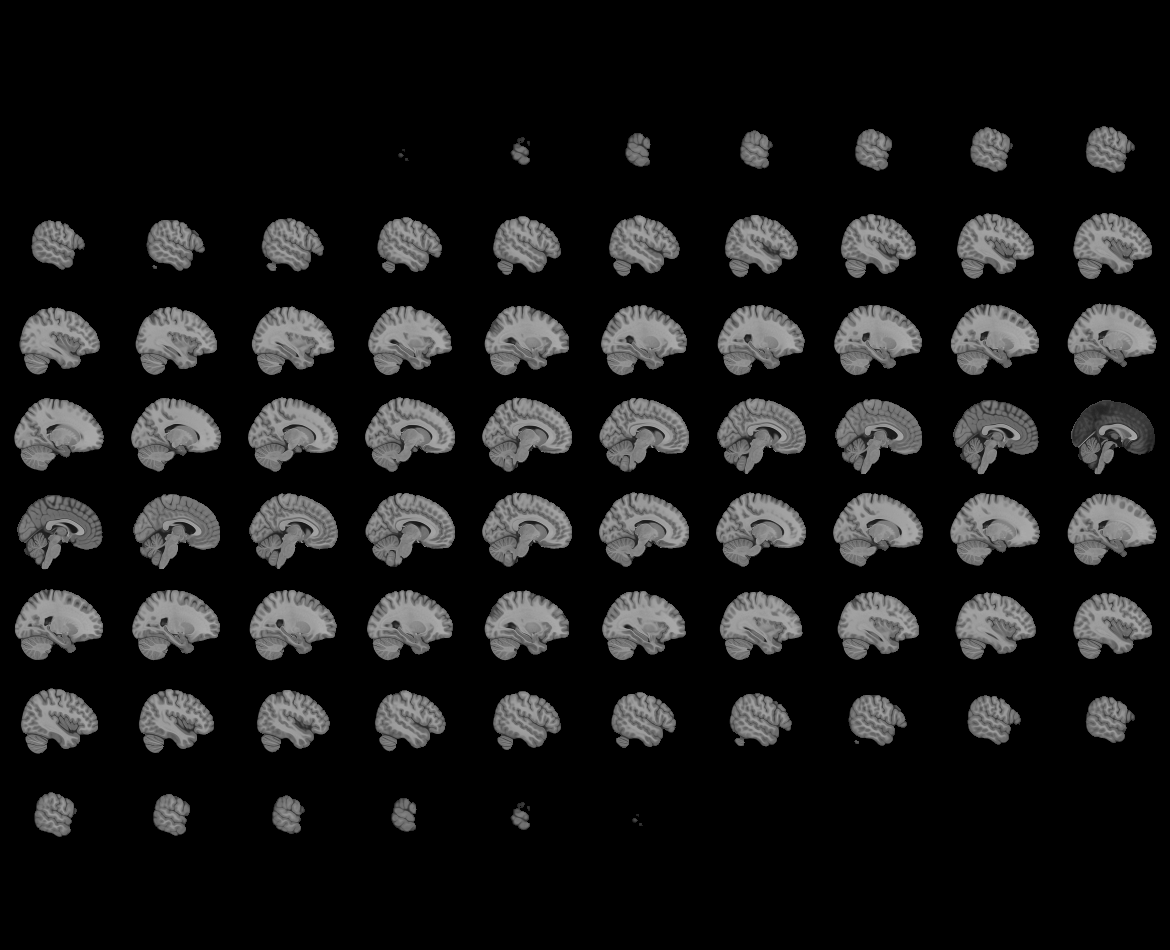
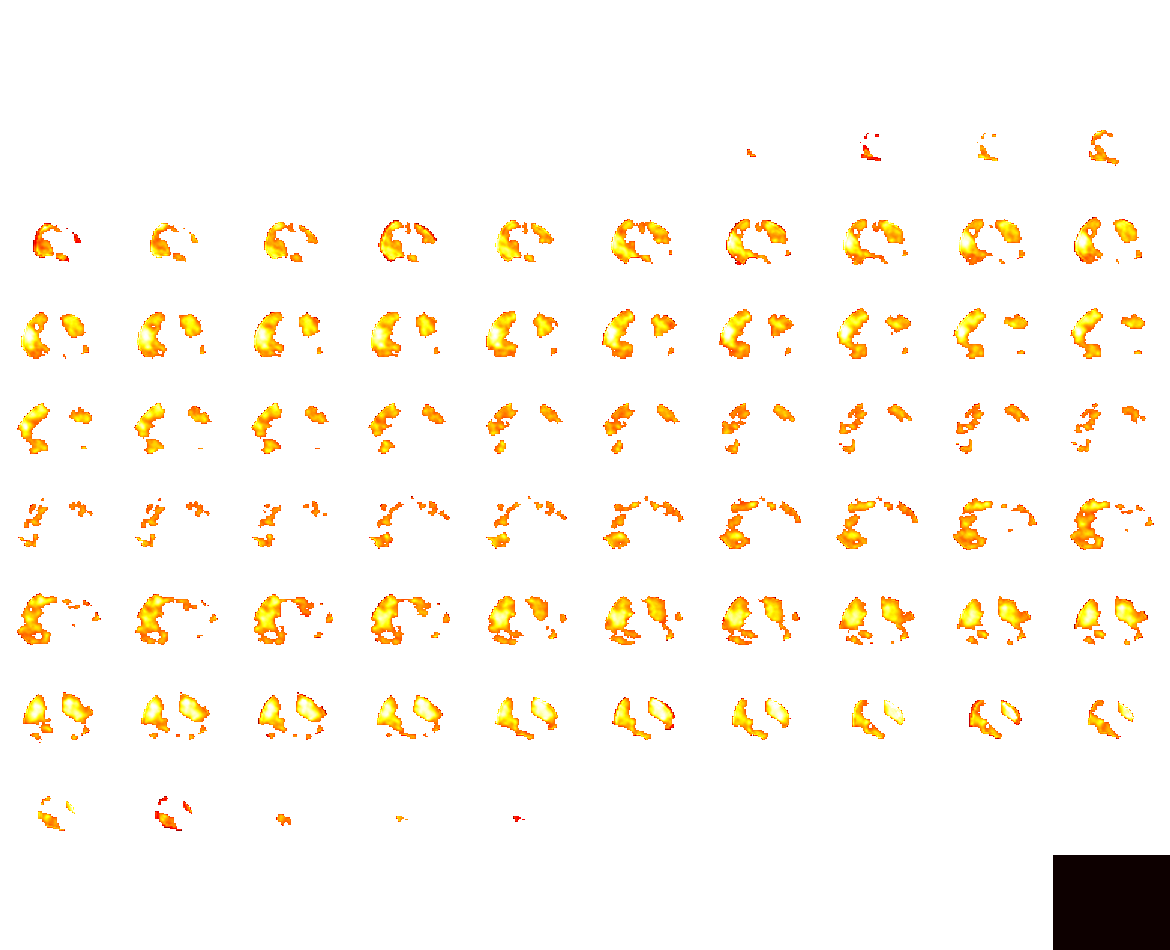

In [23]:
plot_corrected_neglog_pvalue_img = new_img_like(tmp_img, neg_log_corrected_p_brain)
view = plotting.view_img(plot_corrected_neglog_pvalue_img, threshold = 2)
view

In [47]:
nib.save(plot_corrected_neglog_pvalue_img, os.path.join("F:\yujun\projects\IAPS_Searchlight\Searchlight results", 'valence60.nii.gz'))

In [45]:
nib.save(plot_corrected_neglog_pvalue_img, os.path.join("C:/Users/yujunchen/Dropbox (UFL)/Searchlight results", 'valence60.nii.gz'))

### Mask the voxels with significant p-values and plot t statistics

In [24]:
sig_voxel = np.where(corrected_pvalue<0.05)

In [25]:
t_stat_array.shape

(56949,)

In [26]:
x, y, z = mask.shape
# t_stat_sig = np.full(([x*y*z]), np.nan)
t_stat_sig = np.empty([x*y*z])
t_stat_sig[np.array(SL_RDM.rdm_descriptors['voxel_index'])[sig_voxel]] = t_stat_array[sig_voxel]

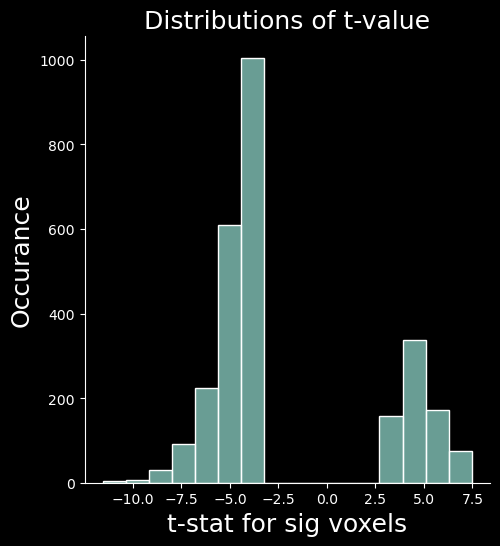

In [28]:
sns.displot(t_stat_array[sig_voxel])
plt.title('Distributions of t-value', size=18)
plt.ylabel('Occurance', size=18)
plt.xlabel('t-stat for sig voxels', size=18)
sns.despine()
plt.show()

In [27]:
t_stat_sig_3d = t_stat_sig.reshape([x, y, z])
t_stat_sig_img = new_img_like(tmp_img, t_stat_sig_3d)
t_stat_sig_img_clsuter = nlimg.threshold_img(t_stat_sig_img, 0, cluster_threshold=9)

c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\numpy\core\fromnumeric.py:758: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



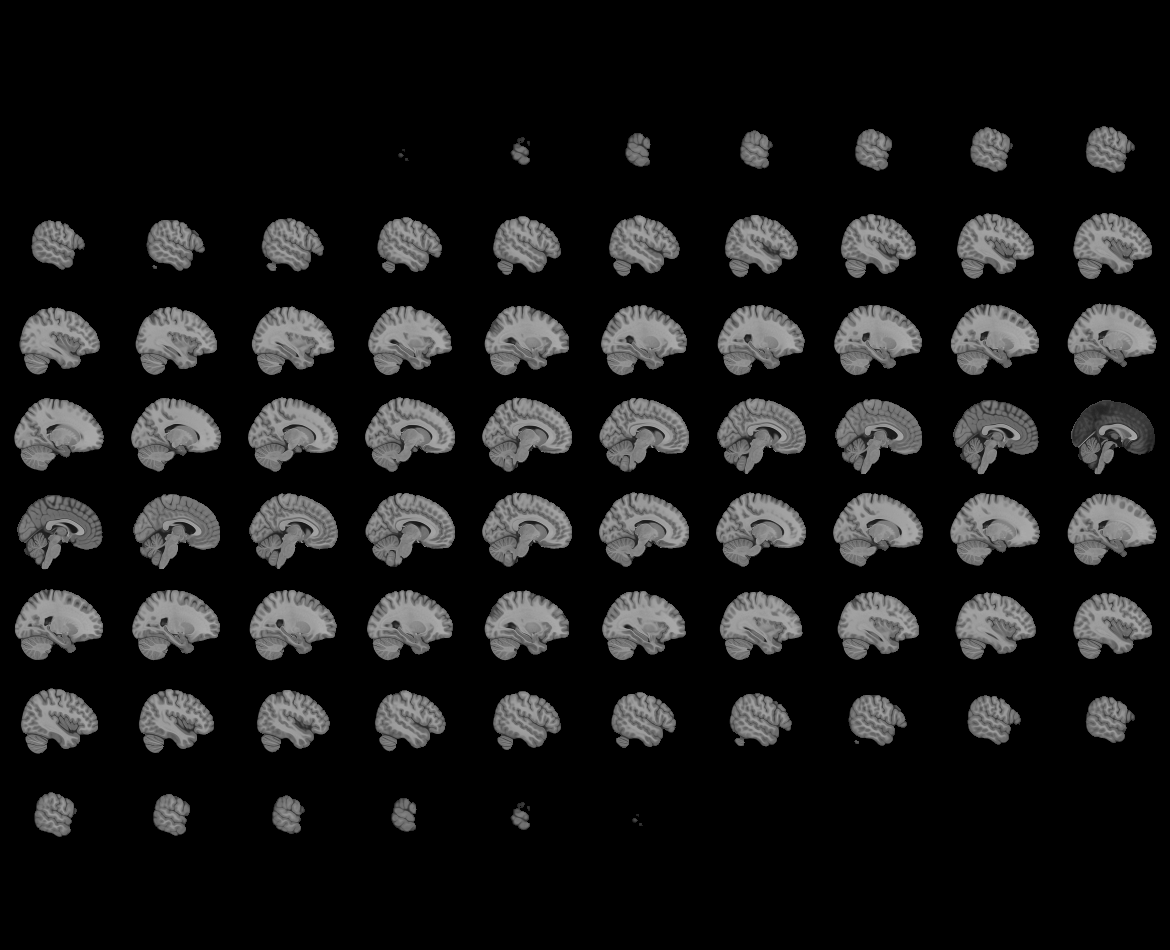
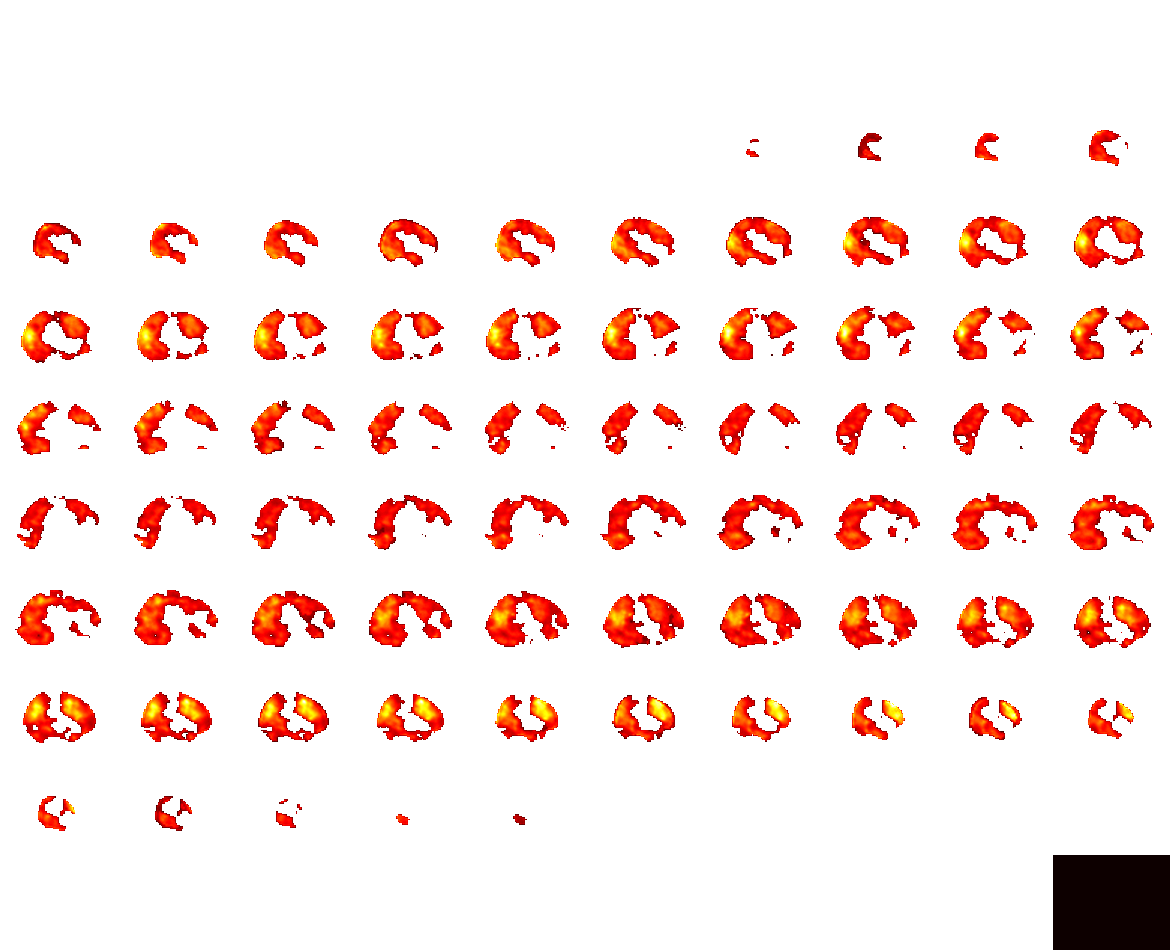

In [28]:
view = plotting.view_img(t_stat_sig_img_clsuter)
view

In [42]:
nib.save(t_stat_sig_img_clsuter, os.path.join("./outputs/tBrainmap", 'tmap_pleasure_p05.nii.gz'))

In [43]:
nib.save(t_stat_sig_img_clsuter, os.path.join("C:/Users/yujunchen/Dropbox (UFL)/Searchlight results", 'tmap_pleasure_p05.nii.gz'))

### Group mean correlation

In [29]:
type(seed_to_voxel_correlations_fisher_z)

numpy.ndarray

In [30]:
mean_correlations_fisher_z = np.mean(seed_to_voxel_correlations_fisher_z, axis=0)

In [31]:
mean_correlations_fisher_z.shape

(56949,)

In [32]:
x, y, z = mask.shape
# t_stat_sig = np.full(([x*y*z]), np.nan)
mean_corr = np.empty([x*y*z])
mean_corr[np.array(SL_RDM.rdm_descriptors['voxel_index'])[sig_voxel]] = mean_correlations_fisher_z[sig_voxel]

In [33]:
mean_corr_3d = mean_corr.reshape([x, y, z])
mean_corr_img = new_img_like(tmp_img, mean_corr_3d)
mean_corr_img_clsuter = nlimg.threshold_img(mean_corr_img, 0, cluster_threshold=9)

c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\numpy\core\fromnumeric.py:758: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



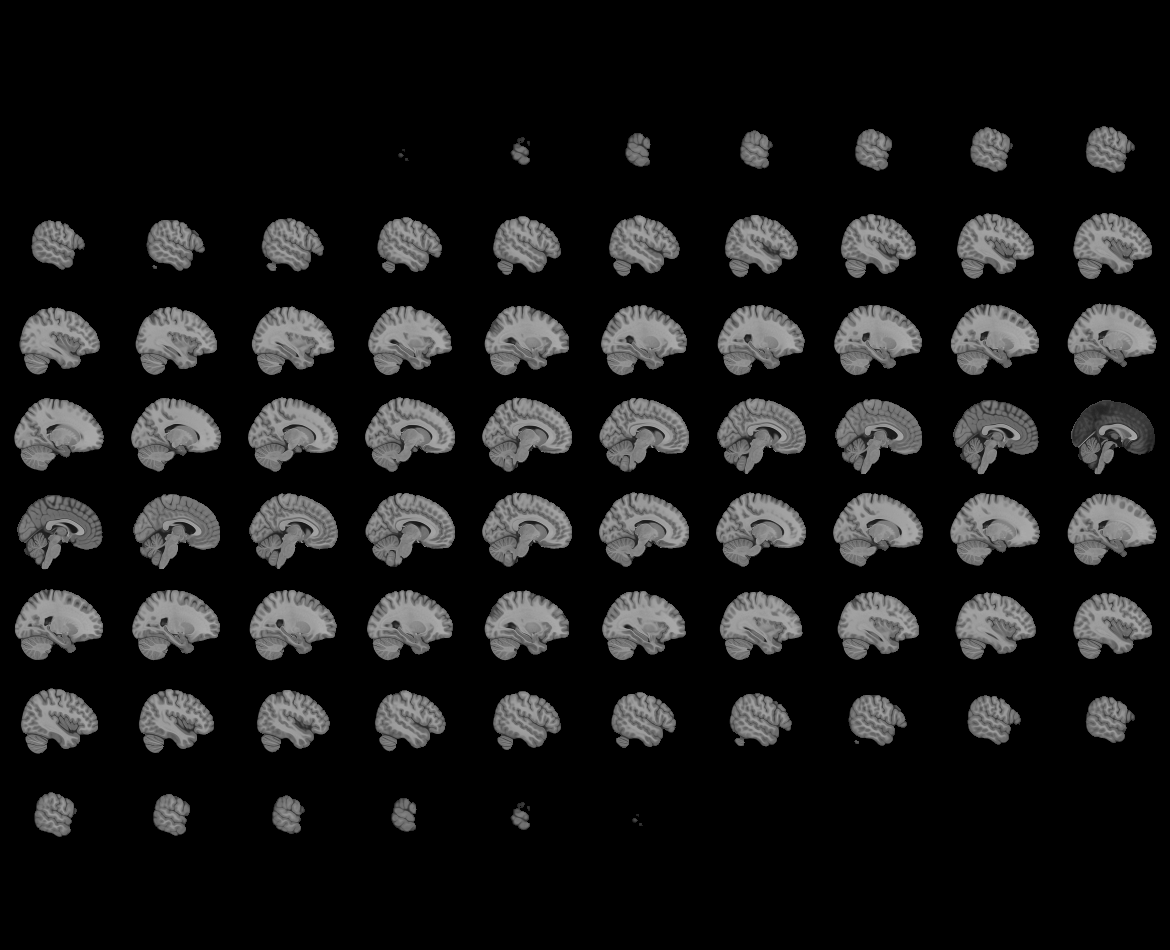
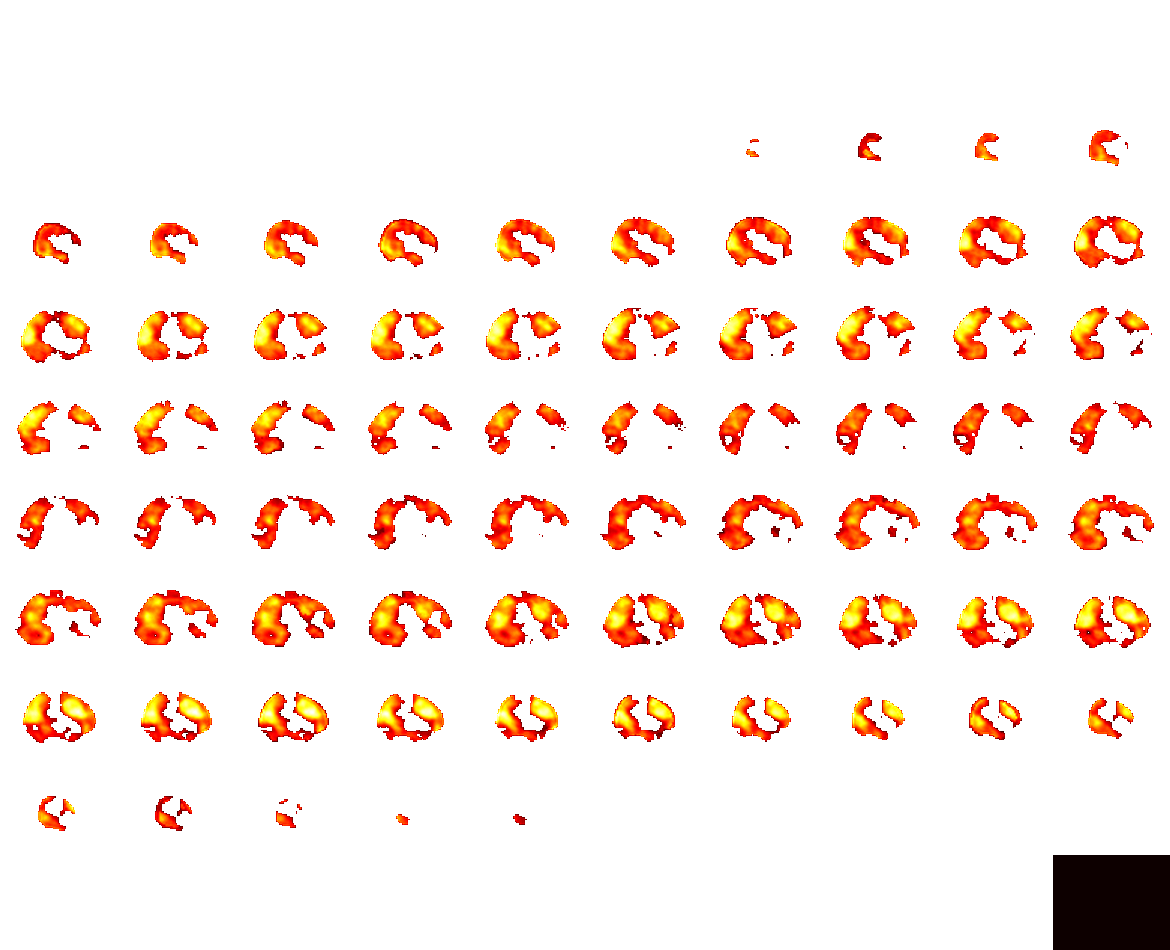

In [34]:
view = plotting.view_img(mean_corr_img_clsuter)
view